---
title: "Power-Flow Analysis"
description: "Solve the built-in IEEE 14-bus benchmark with pandapower."
author: "Samer El Kababji"
date: last-modified
jupyter: python3
format:
  html:
    code-fold: false
    code-links:
      - text: Download notebook
        icon: file-earmark-arrow-down
        href: 1.0-power-flow-analysis.ipynb?download=1
execute:
  echo: true
  warning: false
---

## Setup

This notebook requires Python 3.11 and the packages below. Run this command in a notebook cell once if they are not already installed:

```python
%pip install matplotlib==3.10.8 numpy==2.2.6 pandas==2.3.3 pandapower==3.2.1
```

Restart the kernel after installation, then run the notebook from top to bottom.

In [1]:
#| label: setup
#| echo: true

%matplotlib inline
import json
import logging
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pandapower as pp
import pandapower.networks as pn
from pandapower.plotting import simple_plot

logging.getLogger("pandapower").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message=".*numba cannot be imported.*")
pd.options.display.float_format = "{:,.5f}".format

## Learning objectives

By the end of this notebook, you will be able to:

- distinguish **power flow** from **state estimation**;
- write the nonlinear AC nodal-balance equations;
- identify slack, PV, and PQ bus specifications;
- explain a Newton–Raphson solve; and
- calculate bus voltages, line flows, losses, and loading with pandapower.

In [2]:
#| label: grid-builder
#| echo: true

def build_ieee_14_grid():
    # Load pandapower's built-in IEEE 14-bus benchmark without changing it.
    return pn.case14()


def draw_grid(net, title="The pandapower IEEE 14-bus grid"):
    # case14 includes geographic bus coordinates; simple_plot is a pandapower tool.
    ax = simple_plot(
        net, show_plot=False, bus_size=0.7, line_width=2.0,
        ext_grid_size=1.1, trafo_size=0.8, plot_loads=True,
        plot_gens=True, plot_sgens=True, load_size=0.8,
        gen_size=0.8, sgen_size=0.8,
    )
    for bus, row in net.bus.iterrows():
        point = json.loads(row.geo)["coordinates"]
        ax.annotate(f"Bus {bus + 1}", point, xytext=(7, 7),
                    textcoords="offset points", fontsize=10)
    ax.set_title(title)
    return ax

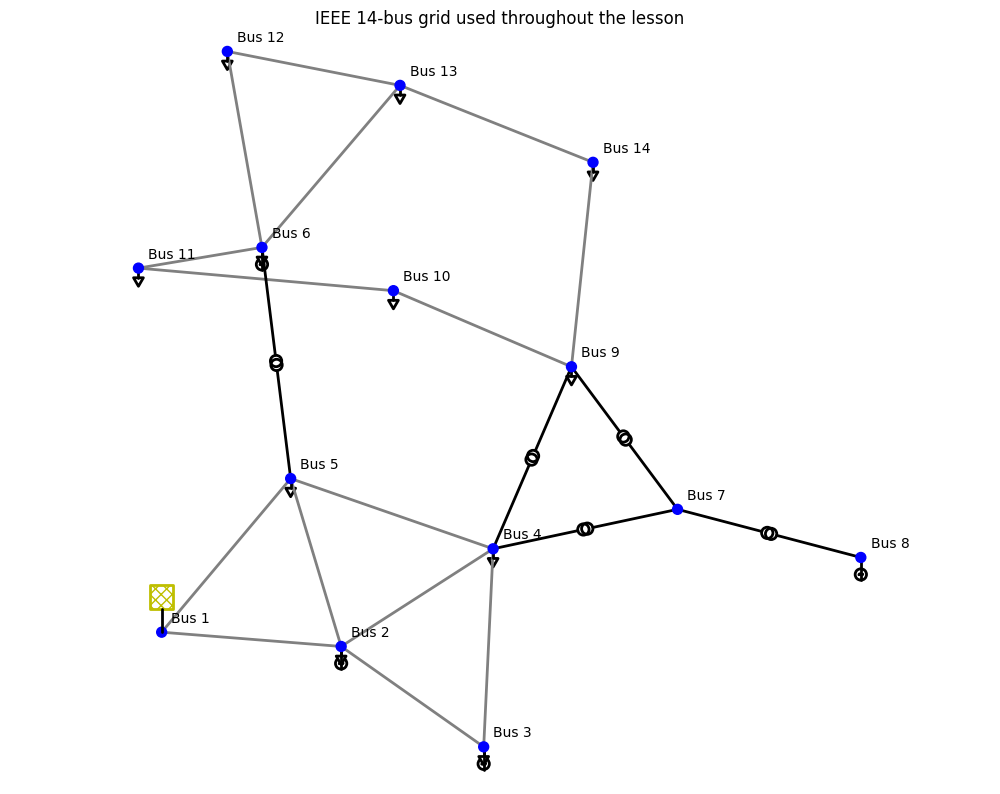

In [3]:
#| label: draw-grid
#| echo: true

net = build_ieee_14_grid()
draw_grid(net, "IEEE 14-bus grid used throughout the lesson")
plt.show()

## 1. Given quantities

A power-flow calculation starts from **specified operating quantities** and a **known network model**. It does not start from noisy meter readings. For the IEEE 14-bus case, the given quantities fall into four groups:

1. the slack-bus voltage magnitude and angle;
2. each generator's active-power set point and voltage-magnitude set point;
3. each demand's active and reactive power; and
4. the topology and electrical parameters of every line, transformer, and shunt.

The bus-type table makes the boundary between inputs and unknowns explicit. Notebook indices are zero-based, while `IEEE bus` below uses the familiar one-based numbering.

In [4]:
#| label: given-bus-types
#| echo: true

slack_buses = set(net.ext_grid.bus.astype(int))
generator_buses = set(net.gen.bus.astype(int))
bus_specification = []
for bus in net.bus.index:
    if bus in slack_buses:
        bus_type, given, solved = "Slack", "|V| and angle", "P and Q"
    elif bus in generator_buses:
        bus_type, given, solved = "PV", "P and |V|", "angle and Q"
    else:
        bus_type, given, solved = "PQ", "P and Q", "|V| and angle"
    bus_specification.append({
        "IEEE bus": bus + 1,
        "type": bus_type,
        "nominal kV": net.bus.at[bus, "vn_kv"],
        "given to power flow": given,
        "calculated by power flow": solved,
    })
pd.DataFrame(bus_specification).set_index("IEEE bus")

,type,nominal kV,given to power flow,calculated by power flow
IEEE bus,,,,
1,Slack,135.00000,|V| and angle,P and Q
2,PV,135.00000,P and |V|,angle and Q
3,PV,135.00000,P and |V|,angle and Q
4,PQ,135.00000,P and Q,|V| and angle
5,PQ,135.00000,P and Q,|V| and angle
6,PV,0.20800,P and |V|,angle and Q
7,PQ,14.00000,P and Q,|V| and angle
8,PV,12.00000,P and |V|,angle and Q
9,PQ,0.20800,P and Q,|V| and angle


### Given operating set points

The following are the numerical source and demand inputs. Generator reactive power is **not** specified at a PV bus; it is calculated to maintain the specified voltage, subject to reactive limits when those limits are enforced. The slack source's $P$ and $Q$ are also outputs.

In [5]:
#| label: given-slack
#| echo: true

external_grid_given = net.ext_grid[["bus", "vm_pu", "va_degree"]].copy()
external_grid_given["bus"] += 1
external_grid_given.rename(columns={"bus": "IEEE bus"})

,IEEE bus,vm_pu,va_degree
0,1,1.06000,0.00000


In [6]:
#| label: given-generators
#| echo: true

generators_given = net.gen[[
    "bus", "p_mw", "vm_pu", "min_q_mvar", "max_q_mvar"
]].copy()
generators_given["bus"] += 1
generators_given.rename(columns={"bus": "IEEE bus"})

,IEEE bus,p_mw,vm_pu,min_q_mvar,max_q_mvar
0,2,40.00000,1.04500,-40.00000,50.00000
1,3,0.00000,1.01000,0.00000,40.00000
2,6,0.00000,1.07000,-6.00000,24.00000
3,8,0.00000,1.09000,-6.00000,24.00000


In [7]:
#| label: given-loads
#| echo: true

loads_given = net.load[["bus", "p_mw", "q_mvar"]].copy()
loads_given["bus"] += 1
loads_given.rename(columns={"bus": "IEEE bus"})

,IEEE bus,p_mw,q_mvar
0,2,21.70000,12.70000
1,3,94.20000,19.00000
2,4,47.80000,-3.90000
3,5,7.60000,1.60000
4,6,11.20000,7.50000
5,9,29.50000,16.60000
6,10,9.00000,5.80000
7,11,3.50000,1.80000
8,12,6.10000,1.60000
9,13,13.50000,5.80000


In [8]:
#| label: given-shunts
#| echo: true

shunts_given = net.shunt[["bus", "p_mw", "q_mvar"]].copy()
shunts_given["bus"] += 1
shunts_given.rename(columns={"bus": "IEEE bus"})

,IEEE bus,p_mw,q_mvar
0,9,0.00000,-19.00000


### Given network model

The branch endpoints define the topology. Line resistance, reactance, capacitance, length, and rating are known; transformer ratings, short-circuit parameters, and tap positions are known. Together with nominal bus voltages and the system base power `net.sn_mva`, these data determine the admittance matrix $Y$.

In [9]:
#| label: given-lines
#| echo: true

lines_given = net.line[[
    "from_bus", "to_bus", "length_km", "r_ohm_per_km",
    "x_ohm_per_km", "c_nf_per_km", "max_i_ka"
]].copy()
lines_given[["from_bus", "to_bus"]] += 1
lines_given.rename(columns={"from_bus": "from IEEE bus", "to_bus": "to IEEE bus"})

,from IEEE bus,to IEEE bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,max_i_ka
0,1,2,1.00000,3.53200,10.78373,768.48477,42.33902
1,1,5,1.00000,9.84697,40.64904,716.08808,42.33902
2,2,3,1.00000,8.56393,36.08003,637.49305,42.33902
3,2,4,1.00000,10.59055,32.13432,494.85762,42.33902
4,2,5,1.00000,10.37914,31.68963,503.59040,42.33902
5,3,4,1.00000,12.21257,31.17022,186.29934,42.33902
6,4,5,1.00000,2.43304,7.67455,0.00000,42.33902
7,6,11,1.00000,0.00004,0.00009,0.00000,"27,479.65224"
8,6,12,1.00000,0.00005,0.00011,0.00000,"27,479.65224"
9,6,13,1.00000,0.00003,0.00006,0.00000,"27,479.65224"


In [10]:
#| label: given-transformers
#| echo: true

transformers_given = net.trafo[[
    "hv_bus", "lv_bus", "sn_mva", "vk_percent", "vkr_percent",
    "tap_side", "tap_neutral", "tap_pos", "tap_step_percent"
]].copy()
transformers_given[["hv_bus", "lv_bus"]] += 1
transformers_given.rename(columns={"hv_bus": "HV IEEE bus", "lv_bus": "LV IEEE bus"})

,HV IEEE bus,LV IEEE bus,sn_mva,vk_percent,vkr_percent,tap_side,tap_neutral,tap_pos,tap_step_percent
0,4,7,"9,900.00000","2,070.28800",0.00000,hv,0.00000,-1.00000,2.20000
1,4,9,"9,900.00000","5,506.18200",0.00000,hv,0.00000,-1.00000,3.10000
2,5,6,"9,900.00000","2,494.99800",0.00000,hv,0.00000,-1.00000,6.80000
3,7,8,"9,900.00000","1,743.88500",0.00000,None,NaN,NaN,NaN
4,7,9,"9,900.00000","1,089.09900",0.00000,None,NaN,NaN,NaN


In [11]:
#| label: given-system-base
#| echo: true

print(f"System base power: {net.sn_mva:.1f} MVA")
print(f"Known topology: {len(net.bus)} buses, {len(net.line)} lines, "
      f"and {len(net.trafo)} transformers")

System base power: 100.0 MVA
Known topology: 14 buses, 15 lines, and 5 transformers


## 2. The engineering question

We use `pandapower.networks.case14()`, pandapower's built-in version of the IEEE 14-bus benchmark. It contains 14 buses, 15 lines, 5 transformers, an external grid, generators, loads, and shunts. All branch parameters and device set points are known.

**Question.** For this operating scenario, what are the voltage magnitude and phase angle at every bus? What active and reactive power flows through every line, what are the losses, and does any line exceed its thermal rating?

This is a **power-flow (load-flow) problem**: inputs are a network model and assumed injections/set points. No meter readings are required.

## 3. AC power-flow equations

Write the bus-voltage state as $V_i=|V_i|e^{j\theta_i}$ and the bus-admittance matrix entry as $Y_{ij}=G_{ij}+jB_{ij}$. With $\theta_{ij}=\theta_i-\theta_j$, the calculated net injections are

$$
P_i=\sum_{j=1}^{n}|V_i||V_j|\left(G_{ij}\cos\theta_{ij}+B_{ij}\sin\theta_{ij}\right),
$$

$$
Q_i=\sum_{j=1}^{n}|V_i||V_j|\left(G_{ij}\sin\theta_{ij}-B_{ij}\cos\theta_{ij}\right).
$$

The balance equations set these calculated injections equal to generation minus demand. Bus types determine which quantities are specified:

| Bus type | Specified | Solved |
|---|---|---|
| Slack | $|V|,\theta$ | $P,Q$ |
| PV (generator) | $P,|V|$ | $\theta,Q$ |
| PQ (load) | $P,Q$ | $|V|,\theta$ |

In this example the external grid is the slack, generator buses are PV buses, and demand buses are PQ buses.

## 4. How Newton–Raphson solves it

At iteration $k$, form the mismatch vector from specified and calculated injections,

$$
g(x^{(k)})=
\begin{bmatrix}\Delta P\\\Delta Q\end{bmatrix},
\qquad
x=\begin{bmatrix}\theta_{\text{non-slack}}\\|V|_{\text{PQ}}\end{bmatrix}.
$$

Linearize with the Jacobian $J=\partial(P,Q)/\partial(\theta,|V|)$ and solve

$$J(x^{(k)})\,\Delta x=g(x^{(k)}),\qquad x^{(k+1)}=x^{(k)}+\Delta x.$$

Iteration stops when the largest mismatch is below a tolerance. This is a square root-finding problem: one assumed operating scenario ideally produces one physically relevant solution.

In [12]:
#| label: solve-power-flow
#| echo: true

pp.runpp(net, algorithm="nr", calculate_voltage_angles=True,
         init="flat", tolerance_mva=1e-8, numba=False)
print(f"Converged: {net.converged}")

Converged: True


## 5. Bus states and line flows

pandapower uses the **consumer convention** in result tables: positive bus $P$ and $Q$ mean net consumption; negative values mean net injection into the grid.

In [13]:
#| label: bus-results
#| echo: true

bus_results = net.res_bus[["vm_pu", "va_degree", "p_mw", "q_mvar"]].copy()
bus_results.index = net.bus.name
bus_results

,vm_pu,va_degree,p_mw,q_mvar
name,,,,
1,1.06000,0.00000,-232.39327,16.54930
2,1.04500,-4.98259,-18.30000,-30.85710
3,1.01000,-12.72510,94.20000,-6.07535
4,1.01767,-10.31290,47.80000,-3.90000
5,1.01951,-8.77385,7.60000,1.60000
6,1.07000,-14.22095,11.20000,-5.23094
7,1.06152,-13.35963,0.00000,0.00000
8,1.09000,-13.35963,0.00000,-17.62345
9,1.05593,-14.93852,29.50000,-4.58484


In [14]:
#| label: line-results
#| echo: true

line_results = net.res_line[[
    "p_from_mw", "q_from_mvar", "p_to_mw", "q_to_mvar", "pl_mw", "loading_percent"
]].copy()
line_results.index = net.line.name
line_results

,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,loading_percent
name,,,,,,
None,156.88289,-20.40429,-152.58529,27.67625,4.29760,1.50757
None,75.51038,3.85499,-72.74751,2.22936,2.76287,0.72110
None,73.23758,3.56020,-70.91431,1.60223,2.32327,0.70940
None,56.13150,-1.55035,-54.45484,3.02069,1.67666,0.54278
None,41.51622,1.17100,-40.61246,-2.09903,0.90375,0.40291
None,-23.28569,4.47312,23.65914,-4.83565,0.37344,0.23969
None,-61.15823,15.82364,61.67265,-14.20100,0.51442,0.62702
None,7.35328,3.56047,-7.29790,-3.44451,0.05537,0.07713
None,7.78607,2.50341,-7.71426,-2.35396,0.07181,0.07721


In [15]:
#| label: transformer-results
#| echo: true

trafo_results = net.res_trafo[[
    "p_hv_mw", "q_hv_mvar", "p_lv_mw", "q_lv_mvar", "pl_mw", "loading_percent"
]].copy()
trafo_results.index = [f"Transformer {i}" for i in net.trafo.index]
trafo_results

,p_hv_mw,q_hv_mvar,p_lv_mw,q_lv_mvar,pl_mw,loading_percent
Transformer 0,28.07418,-9.68107,-28.07418,11.38428,0.00000,0.29476
Transformer 1,16.07976,-0.42761,-16.07976,1.73232,-0.00000,0.15966
Transformer 2,44.08732,12.47068,-44.08732,-8.04952,0.00000,0.45394
Transformer 3,0.00000,-17.16297,-0.00000,17.62345,0.00000,0.16332
Transformer 4,28.07418,5.77869,-28.07418,-4.97662,0.00000,0.27274


In [16]:
#| label: summary
#| echo: true

summary = pd.Series({
    "minimum voltage (pu)": net.res_bus.vm_pu.min(),
    "total branch active loss (MW)": net.res_line.pl_mw.sum() + net.res_trafo.pl_mw.sum(),
    "maximum branch loading (%)": max(net.res_line.loading_percent.max(), net.res_trafo.loading_percent.max()),
})
summary

minimum voltage (pu)             1.01000
total branch active loss (MW)   13.39327
maximum branch loading (%)       1.50757
dtype: float64

## 6. Interpretation and the bridge to state estimation

The solution predicts the complete electrical condition from specified loads, generation, and the network model. In a control room, however, the actual loads are not known perfectly and meters contain noise. **State estimation reverses the information flow:** it uses redundant, imperfect measurements to infer the most plausible bus voltages, then derives injections and line flows from those estimated states.

### Check your understanding

1. Increase the first load by 20%. Which bus voltage changes most?
2. Open line 3 with `net.line.at[3, "in_service"] = False`. Does the case converge, and which branch loading changes most?
3. Why does the slack-grid active power differ from the net specified demand?